# Geometric Distribution: "How long until the first success?"

The **binomial** distribution asks: *"In n trials, how many successes?"*
The **geometric** distribution flips the question: *"How many trials until the first success?"*

**Contents**
1. Setup
2. The idea and the formula (PMF)
3. Two conventions (trials vs failures): don't mix them up!
4. Building the formula by hand
5. CDF, survival function and "at least / more than" questions
6. Mean and variance (with proofs)
7. Shape of the distribution
8. Memoryless property (and the gambler's fallacy)
9. Simulation check
10. **Real-life case study 1:** Sales calls
11. **Real-life case study 2:** Quality inspection line
12. **Real-life case study 3:** Cricket / free-throw / online conversion, and a "cost of waiting" model
13. Estimating p from real data (MLE)
14. Geometric vs Binomial vs Negative Binomial
15. Key insights, cheat-sheet & practice

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from math import ceil, log

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(11)

## 2. The Idea and the Formula

Run **independent Bernoulli trials**, each with success probability **p** (failure probability $q = 1-p$), and **stop at the first success**.

Let X = the **trial number on which the first success occurs**. Then X ~ Geometric(p):

$$\boxed{P(X=k)=(1-p)^{k-1}\,p,\qquad k=1,2,3,\dots}$$

Reading the formula: to get the first success on trial *k*, you need
* **k − 1 failures** in a row, probability $(1-p)^{k-1}$, and then
* **1 success** on trial k, probability $p$.

**Conditions**
1. Each trial has two outcomes: success / failure.
2. Trials are **independent**.
3. **p is constant** across trials.
4. We count trials **until the first success** (the number of trials is *not* fixed in advance).

Support is infinite (1, 2, 3, ...), yet the probabilities still sum to 1 (a geometric series):

$$\sum_{k=1}^\infty (1-p)^{k-1}p=\frac{p}{1-(1-p)}=1$$

In [2]:
def geom_pmf(k, p):
    return (1 - p)**(k - 1) * p

p = 1/6           # rolling a die until we see a six
for k in range(1, 8):
    print(f"P(first six on roll {k}) = (5/6)^{k-1} * (1/6) = {geom_pmf(k, p):.4f}")

print("\nSum of first 200 terms:", sum(geom_pmf(k, p) for k in range(1, 201)))
print("scipy check P(X=3):", stats.geom.pmf(3, p), " vs manual:", geom_pmf(3, p))

P(first six on roll 1) = (5/6)^0 * (1/6) = 0.1667
P(first six on roll 2) = (5/6)^1 * (1/6) = 0.1389
P(first six on roll 3) = (5/6)^2 * (1/6) = 0.1157
P(first six on roll 4) = (5/6)^3 * (1/6) = 0.0965
P(first six on roll 5) = (5/6)^4 * (1/6) = 0.0804
P(first six on roll 6) = (5/6)^5 * (1/6) = 0.0670
P(first six on roll 7) = (5/6)^6 * (1/6) = 0.0558

Sum of first 200 terms: 1.0
scipy check P(X=3): 0.11574074074074076  vs manual: 0.11574074074074076


## 3. Two Conventions (Important!)

Textbooks differ. Always check which one is being used:

| Convention | Random variable | Support | PMF | Mean | Variance |
|---|---|---|---|---|---|
| **A: trials until 1st success** (used here, and by `scipy.stats.geom`) | X = trial number of first success | 1, 2, 3, ... | $(1-p)^{k-1}p$ | $\dfrac1p$ | $\dfrac{1-p}{p^2}$ |
| **B: failures before 1st success** (used by many textbooks; numpy and scipy both use A) | Y = X − 1 | 0, 1, 2, ... | $(1-p)^{k}p$ | $\dfrac{1-p}{p}$ | $\dfrac{1-p}{p^2}$ |

They differ only by a shift of 1: $Y = X - 1$. The variance is identical; the mean differs by 1.

In [3]:
p = 0.25
X = stats.geom(p)                     # convention A (trials)
print("Convention A mean (trials)  :", X.mean(), "= 1/p =", 1/p)
print("Convention B mean (failures):", X.mean() - 1, "= (1-p)/p =", (1-p)/p)
print("Variance (both)             :", X.var(), "= (1-p)/p^2 =", (1-p)/p**2)

# scipy can shift with loc=-1 to get convention B
Y = stats.geom(p, loc=-1)
print("\nP(X=3) [3rd trial]      :", round(X.pmf(3), 5))
print("P(Y=2) [2 failures first]:", round(Y.pmf(2), 5), " (same event)")

Convention A mean (trials)  : 4.0 = 1/p = 4.0
Convention B mean (failures): 3.0 = (1-p)/p = 3.0
Variance (both)             : 12.0 = (1-p)/p^2 = 12.0

P(X=3) [3rd trial]      : 0.14062
P(Y=2) [2 failures first]: 0.14062  (same event)


## 4. Building the Formula by Hand

Let's list what has to happen for the first success (p = 0.3) to occur on trial 1, 2, 3, 4 and visualise it.

In [4]:
p, q = 0.3, 0.7
rows = []
for k in range(1, 6):
    seq = "F" * (k - 1) + "S"
    rows.append({"first success on trial": k, "sequence": seq,
                 "probability": f"{q}^{k-1} × {p}", "value": q**(k-1) * p})
print(pd.DataFrame(rows).round(4).to_string(index=False))

 first success on trial sequence probability  value
                      1        S 0.7^0 × 0.3 0.3000
                      2       FS 0.7^1 × 0.3 0.2100
                      3      FFS 0.7^2 × 0.3 0.1470
                      4     FFFS 0.7^3 × 0.3 0.1029
                      5    FFFFS 0.7^4 × 0.3 0.0720


In [5]:
# Simulation of a few "experiments" to see how random the waiting time is
p = 0.3
print("Ten independent experiments: 'toss until success'")
for i in range(10):
    seq, k = "", 0
    while True:
        k += 1
        if rng.random() < p:
            seq += "S"; break
        seq += "F"
    print(f"  experiment {i+1:2d}: {seq:<15s} -> X = {k}")

Ten independent experiments: 'toss until success'
  experiment  1: S               -> X = 1
  experiment  2: FFS             -> X = 3
  experiment  3: S               -> X = 1
  experiment  4: FS              -> X = 2
  experiment  5: S               -> X = 1
  experiment  6: FFFFFS          -> X = 6
  experiment  7: S               -> X = 1
  experiment  8: FFFFFFS         -> X = 7
  experiment  9: FFFFS           -> X = 5
  experiment 10: FFS             -> X = 3


## 5. CDF, Survival Function & Range Questions

Probability that the first success happens **within the first k trials**:

$$F(k)=P(X\le k)=1-(1-p)^k$$

Reason: the *only* way to have no success in k trials is k failures in a row, with probability $q^k$.

Probability you need **more than k trials** (survival function):

$$P(X>k)=(1-p)^k$$

| Question | Formula | scipy |
|---|---|---|
| Exactly k | $q^{k-1}p$ | `pmf(k)` |
| At most k trials | $1-q^k$ | `cdf(k)` |
| More than k trials | $q^k$ | `sf(k)` |
| At least k trials | $q^{k-1}$ | `sf(k-1)` |
| Between a and b | $q^{a-1} - q^{b}$ | `cdf(b)-cdf(a-1)` |

In [6]:
p = 0.2
X = stats.geom(p)
q = 1 - p

print("P(X = 4)          =", round(X.pmf(4), 4))
print("P(X <= 4)         =", round(X.cdf(4), 4), "  formula 1-q^4 =", round(1 - q**4, 4))
print("P(X > 4)          =", round(X.sf(4), 4),  "  formula q^4   =", round(q**4, 4))
print("P(X >= 4)         =", round(X.sf(3), 4),  "  formula q^3   =", round(q**3, 4))
print("P(3 <= X <= 6)    =", round(X.cdf(6) - X.cdf(2), 4))

P(X = 4)          = 0.1024
P(X <= 4)         = 0.5904   formula 1-q^4 = 0.5904
P(X > 4)          = 0.4096   formula q^4   = 0.4096
P(X >= 4)         = 0.512   formula q^3   = 0.512
P(3 <= X <= 6)    = 0.3779


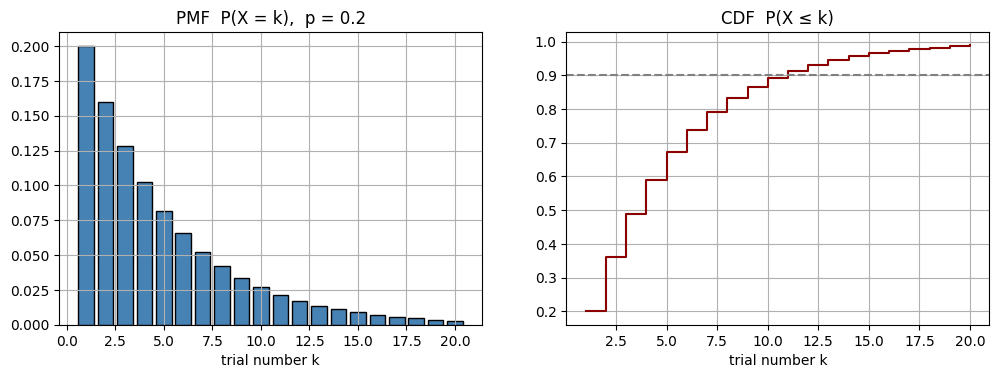

In [7]:
k = np.arange(1, 21)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].bar(k, X.pmf(k), color="steelblue", edgecolor="black"); ax[0].set_title("PMF  P(X = k),  p = 0.2")
ax[1].step(k, X.cdf(k), where="post", color="darkred"); ax[1].set_title("CDF  P(X ≤ k)")
ax[1].axhline(0.9, ls="--", color="gray")
for a in ax: a.set_xlabel("trial number k")
plt.show()

## 6. Mean and Variance

$$\boxed{E[X]=\frac1p}\qquad\qquad\boxed{\text{Var}(X)=\frac{1-p}{p^2}}\qquad\qquad\sigma=\frac{\sqrt{1-p}}{p}$$

### Proof of the mean (quick, using conditioning)
Look at the first trial:
* With probability p it's a success, so X = 1.
* With probability q it's a failure; then we've "used up" one trial and the process starts afresh (independence), so X = 1 + X'.

$$E[X]=p\cdot1+q\,(1+E[X])\;\Longrightarrow\;E[X]=1+qE[X]\;\Longrightarrow\;E[X]=\frac{1}{1-q}=\frac1p$$

### Proof of the variance (same trick)
$E[X^2]=p\cdot1+q\,E[(1+X)^2]=p+q(1+2E[X]+E[X^2])$. Solve for $E[X^2]$:

$$E[X^2]=\frac{2-p}{p^2}\;\Longrightarrow\;\text{Var}(X)=\frac{2-p}{p^2}-\frac1{p^2}=\frac{1-p}{p^2}$$

**Intuition**
* If success probability is 1/10, you expect to wait ~10 trials.
* The **standard deviation is almost as large as the mean** when p is small (σ ≈ μ). Waiting times are highly unpredictable.

In [8]:
p = 0.15
k = np.arange(1, 2000)                      # long enough to capture almost all probability
pmf = geom_pmf(k, p)

mean_num = np.sum(k * pmf)
ex2_num  = np.sum(k**2 * pmf)
var_num  = ex2_num - mean_num**2

print(f"E[X]   numeric: {mean_num:.5f}   formula 1/p       : {1/p:.5f}")
print(f"E[X^2] numeric: {ex2_num:.5f}   formula (2-p)/p^2  : {(2-p)/p**2:.5f}")
print(f"Var    numeric: {var_num:.5f}   formula (1-p)/p^2  : {(1-p)/p**2:.5f}")
print(f"SD = {np.sqrt(var_num):.3f}  vs mean = {mean_num:.3f}   (SD/mean = {np.sqrt(var_num)/mean_num:.3f})")

E[X]   numeric: 6.66667   formula 1/p       : 6.66667
E[X^2] numeric: 82.22222   formula (2-p)/p^2  : 82.22222
Var    numeric: 37.77778   formula (1-p)/p^2  : 37.77778
SD = 6.146  vs mean = 6.667   (SD/mean = 0.922)


In [9]:
# Mean and SD as p changes
ps = np.array([0.5, 0.25, 0.1, 0.05, 0.01])
summary = pd.DataFrame({
    "p": ps,
    "mean 1/p": 1/ps,
    "SD sqrt(1-p)/p": np.sqrt(1 - ps)/ps,
    "median": [stats.geom.median(pp) for pp in ps],
    "mode": 1,
})
print(summary.round(2).to_string(index=False))
print("\nNote: the MODE is always 1, and the median is LESS than the mean (right-skewed).")

   p  mean 1/p  SD sqrt(1-p)/p  median  mode
0.50       2.0            1.41     1.0     1
0.25       4.0            3.46     3.0     1
0.10      10.0            9.49     7.0     1
0.05      20.0           19.49    14.0     1
0.01     100.0           99.50    69.0     1

Note: the MODE is always 1, and the median is LESS than the mean (right-skewed).


## 7. Shape of the Distribution

* The PMF is **always decreasing**. The most likely single outcome is **k = 1** (immediate success).
* It has a **long right tail**: occasionally you wait a very long time.
* Small p → flatter and wider; large p → steep and concentrated near 1.
* Mean > median > mode (positively skewed).

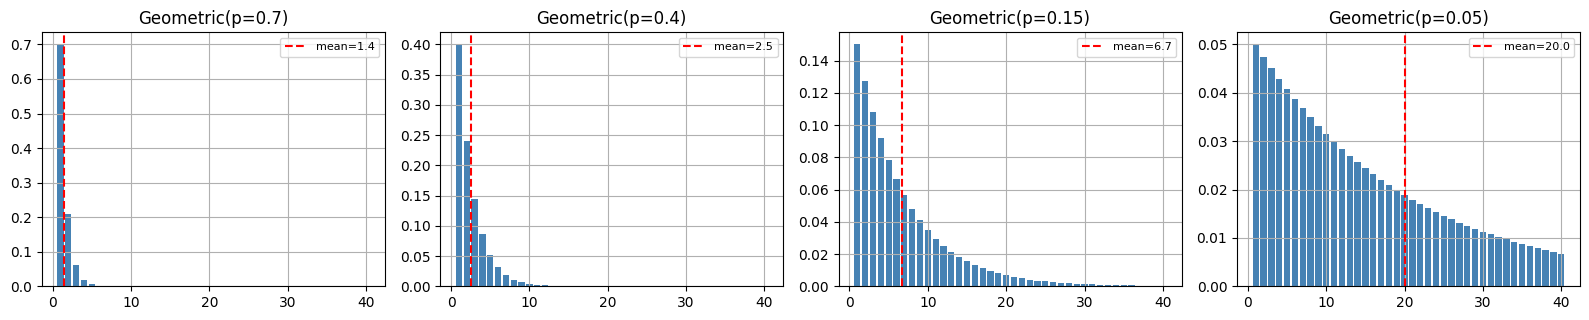

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.3), sharey=False)
for ax, p_ in zip(axes, [0.7, 0.4, 0.15, 0.05]):
    k = np.arange(1, 41)
    ax.bar(k, stats.geom.pmf(k, p_), color="steelblue")
    ax.axvline(1/p_, color="red", ls="--", label=f"mean={1/p_:.1f}")
    ax.set_title(f"Geometric(p={p_})"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. The Memoryless Property

$$P(X>s+t\mid X>s)=P(X>t)$$

*Given that you have already failed s times, the chance of needing more than t **additional** trials is exactly the same as if you were starting from scratch.* The process doesn't "remember" its failures.

**Gambler's fallacy:** "I've had 9 tails in a row, heads is *due*." ❌ Wrong. The coin has no memory.

Proof: $\dfrac{P(X>s+t)}{P(X>s)}=\dfrac{q^{s+t}}{q^s}=q^t=P(X>t)$.

The geometric distribution is the **only** discrete memoryless distribution.

In [11]:
p = 0.1
X = stats.geom(p)

s, t = 10, 5
lhs = X.sf(s + t) / X.sf(s)
rhs = X.sf(t)
print(f"P(X > {s+t} | X > {s}) = {lhs:.5f}")
print(f"P(X > {t})            = {rhs:.5f}")

# Empirical demonstration
sim = rng.geometric(p, 1_000_000)
survivors = sim[sim > s]
print("\nAmong people who already failed 10 times:")
print("   fraction needing >5 more tries :", round(np.mean(survivors - s > t), 4))
print("Fresh start, fraction needing >5  :", round(np.mean(sim > t), 4))
print("Average EXTRA wait after 10 failures:", round((survivors - s).mean(), 3), " (still 1/p =", 1/p, ")")

P(X > 15 | X > 10) = 0.59049
P(X > 5)            = 0.59049

Among people who already failed 10 times:
   fraction needing >5 more tries : 0.5894
Fresh start, fraction needing >5  : 0.5909
Average EXTRA wait after 10 failures: 9.984  (still 1/p = 10.0 )


## 9. Simulation Check

Simulated mean = 4.994   theory = 5.0
Simulated var  = 19.961   theory = 19.999999999999996


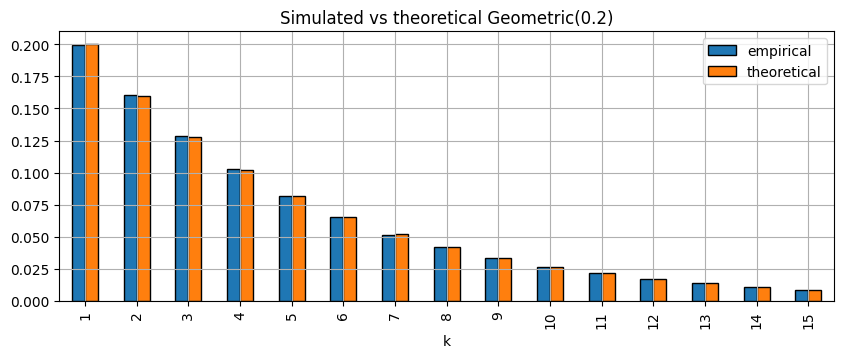

In [12]:
p, reps = 0.2, 500_000
sim = rng.geometric(p, reps)                     # numpy uses convention A (trials)

print(f"Simulated mean = {sim.mean():.3f}   theory = {1/p}")
print(f"Simulated var  = {sim.var():.3f}   theory = {(1-p)/p**2}")

emp = pd.Series(sim).value_counts(normalize=True).sort_index().iloc[:15]
theo = pd.Series(stats.geom.pmf(emp.index, p), index=emp.index)
pd.DataFrame({"empirical": emp, "theoretical": theo}).plot(kind="bar", figsize=(10, 3.5), edgecolor="black")
plt.title("Simulated vs theoretical Geometric(0.2)"); plt.xlabel("k"); plt.show()

---
# Real-Life Case Studies & Insights
---

## 10. Case Study 1: Sales Calls

A telesales agent knows historically that **8% of cold calls end in a sale** (p = 0.08). Calls are independent.
The agent keeps calling until the **first sale**. X = number of calls needed.

**Questions a manager would ask**
1. What's the expected number of calls per sale?
2. What's the chance the first sale comes on the very first call?
3. What's the chance of getting a sale within 10 calls? within 25 calls?
4. How many calls are needed to be **90% / 95% confident** of at least one sale?
5. What is the chance the agent goes 30+ calls with no sale (a "dry spell")?

In [13]:
p = 0.08
X = stats.geom(p)

print(f"1. Expected calls per sale     : {X.mean():.2f}  (SD = {X.std():.2f})")
print(f"2. P(sale on 1st call)         : {X.pmf(1):.3f}")
print(f"3. P(sale within 10 calls)     : {X.cdf(10):.3f}")
print(f"   P(sale within 25 calls)     : {X.cdf(25):.3f}")

# Smallest k such that P(X <= k) >= target:  k >= ln(1-target)/ln(1-p)
for target in (0.5, 0.9, 0.95, 0.99):
    k_formula = ceil(log(1 - target) / log(1 - p))
    print(f"4. Calls needed for {target:.0%} confidence of >=1 sale: {k_formula}   (scipy ppf: {int(X.ppf(target))})")

print(f"5. P(30+ calls with no sale)   : {X.sf(29):.3f}   (i.e. dry spell of 29+ failures)")

1. Expected calls per sale     : 12.50  (SD = 11.99)
2. P(sale on 1st call)         : 0.080
3. P(sale within 10 calls)     : 0.566
   P(sale within 25 calls)     : 0.876
4. Calls needed for 50% confidence of >=1 sale: 9   (scipy ppf: 9)
4. Calls needed for 90% confidence of >=1 sale: 28   (scipy ppf: 28)
4. Calls needed for 95% confidence of >=1 sale: 36   (scipy ppf: 36)
4. Calls needed for 99% confidence of >=1 sale: 56   (scipy ppf: 56)
5. P(30+ calls with no sale)   : 0.089   (i.e. dry spell of 29+ failures)


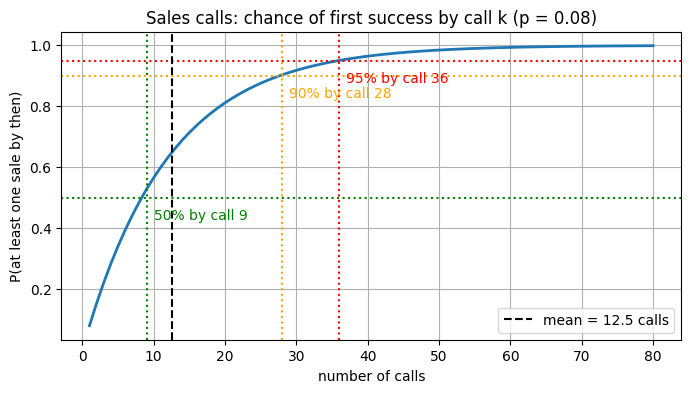

In [14]:
# Visual: probability of having made the first sale by call k
k = np.arange(1, 81)
plt.plot(k, X.cdf(k), lw=2)
for target, col in [(0.5, "green"), (0.9, "orange"), (0.95, "red")]:
    kk = int(X.ppf(target))
    plt.axhline(target, ls=":", color=col); plt.axvline(kk, ls=":", color=col)
    plt.annotate(f"{target:.0%} by call {kk}", (kk + 1, target - 0.07), color=col)
plt.axvline(X.mean(), color="k", ls="--", label=f"mean = {X.mean():.1f} calls")
plt.xlabel("number of calls"); plt.ylabel("P(at least one sale by then)")
plt.title("Sales calls: chance of first success by call k (p = 0.08)"); plt.legend(); plt.show()

### 💡 Insights from Case Study 1
* **Expected** wait is 12.5 calls, but the **median is only 9**: half of the time the sale comes by call 9, yet a few unlucky streaks drag the *average* up. Mean > median is the signature of a right-skewed distribution.
* Being "average" isn't enough: to be **95% sure** of a sale you need ~36 calls, almost **3× the mean**.
* **Standard deviation ≈ mean** (about 12 vs 12.5). Don't judge an agent as "bad" after a 20-call dry spell. It happens ~19% of the time by pure luck.
* **Memoryless**: after 20 failed calls, the next call is *still* an 8% chance. Persistence isn't "due" luck, and the agent shouldn't get discouraged or change scripts based on the streak alone.

count    10000.00
mean        12.67
std         12.05
min          1.00
25%          4.00
50%          9.00
75%         18.00
90%         28.00
95%         36.00
99%         55.00
max        147.00
dtype: float64


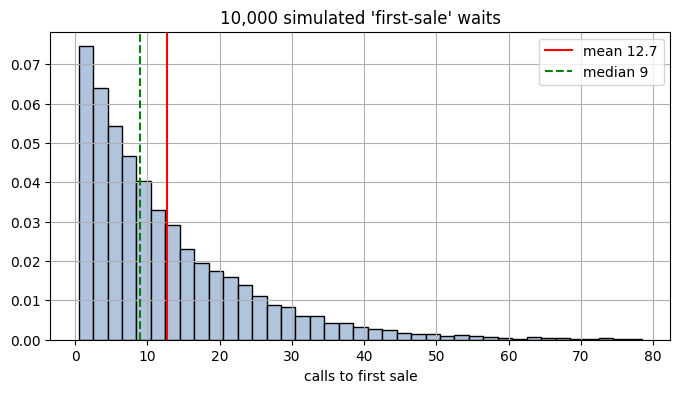

In [15]:
# Simulate 10,000 agent-days: how many calls does each first sale take? Show how erratic it is.
calls_needed = rng.geometric(p, 10_000)
print(pd.Series(calls_needed).describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(2))

plt.hist(calls_needed, bins=np.arange(0.5, 80.5, 2), color="lightsteelblue", edgecolor="black", density=True)
plt.axvline(calls_needed.mean(), color="red", label=f"mean {calls_needed.mean():.1f}")
plt.axvline(np.median(calls_needed), color="green", ls="--", label=f"median {np.median(calls_needed):.0f}")
plt.legend(); plt.xlabel("calls to first sale"); plt.title("10,000 simulated 'first-sale' waits"); plt.show()

## 11. Case Study 2: Quality-Inspection Line

A factory inspects items one by one from a production line where **2% of items are defective** (p = 0.02).
Here "success" = **finding a defective item** (the event we're waiting for). X = number of items inspected until the first defect is found.

**Questions**
1. On average, how many items are inspected before a defect appears?
2. The line runs 1,000 items/hour. How many defects per hour should we expect? Does it agree with 1/p?
3. If an alarm is designed to fire when **150 consecutive items** have no defect, how often is that a false alarm on a *healthy* line (p = 0.02)?
4. If the process degrades to p = 0.05, how does the mean run length change, and how likely is a 150-run then?

In [16]:
p_ok, p_bad = 0.02, 0.05

X_ok, X_bad = stats.geom(p_ok), stats.geom(p_bad)
print(f"1. Mean items until first defect (p=2%): {X_ok.mean():.0f}   (SD {X_ok.std():.1f})")
print(f"2. Defects in 1000 items: expected {1000*p_ok:.0f}  (binomial mean np),  1 defect every {1/p_ok:.0f} items on average (geometric mean 1/p)")

print(f"\n3. P(150+ consecutive good items | healthy line p=2%) = P(X > 150) = {X_ok.sf(150):.4f}")
print(f"4. Degraded line p=5%: mean run = {X_bad.mean():.0f}; P(X > 150) = {X_bad.sf(150):.6f}")

1. Mean items until first defect (p=2%): 50   (SD 49.5)
2. Defects in 1000 items: expected 20  (binomial mean np),  1 defect every 50 items on average (geometric mean 1/p)

3. P(150+ consecutive good items | healthy line p=2%) = P(X > 150) = 0.0483
4. Degraded line p=5%: mean run = 20; P(X > 150) = 0.000456


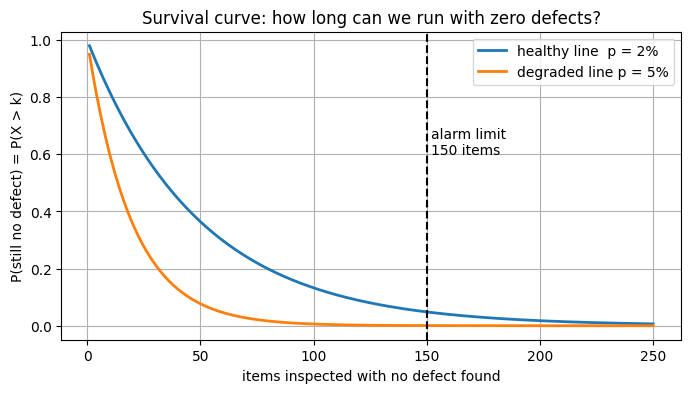

In [17]:
k = np.arange(1, 251)
plt.plot(k, X_ok.sf(k), label="healthy line  p = 2%", lw=2)
plt.plot(k, X_bad.sf(k), label="degraded line p = 5%", lw=2)
plt.axvline(150, color="k", ls="--"); plt.text(152, 0.6, "alarm limit\n150 items")
plt.xlabel("items inspected with no defect found"); plt.ylabel("P(still no defect) = P(X > k)")
plt.title("Survival curve: how long can we run with zero defects?"); plt.legend(); plt.show()

### 💡 Insights from Case Study 2
* Geometric ↔ Binomial link: 1 defect per **1/p = 50 items** ⟺ **np = 20 defects** per 1,000 items. Same p, two views of the same process.
* A run of 150 clean items happens by chance ~5% of the time on a *healthy* line. A control chart that fires after 150 will raise false alarms about 1 in 20 runs.
* If the process worsens to 5%, a 150-item run drops to ~0.04% and becomes a *strong* signal of change. Geometric waiting times are the basis of **run-length monitoring** in quality control (ARL: Average Run Length).
* **Design trade-off:** a longer alarm limit → fewer false alarms but slower detection.

## 12. Case Study 3: Persistence, Cost & the Value of "Trying Again"

**Scenario:** A job seeker applies to companies. Historically, 1 in 12 applications converts to an interview (p ≈ 0.0833). Each application costs about ₹50 (time/certificate/courier). Independent applications assumed.

Let X = applications until the **first interview**. Expected cost = 50 × E[X].

In [18]:
p, cost = 1/12, 50
X = stats.geom(p)

print(f"Expected applications to first interview : {X.mean():.1f}")
print(f"Expected total cost                      : ₹{cost * X.mean():.0f}")
print(f"Standard deviation of applications       : {X.std():.1f}")

# Budget planning: how many applications should you budget for?
print("\nBudget planning")
rows = []
for conf in (0.5, 0.75, 0.9, 0.95, 0.99):
    k = int(X.ppf(conf))
    rows.append({"confidence of ≥1 interview": f"{conf:.0%}", "applications needed": k, "budget (₹)": k * cost})
print(pd.DataFrame(rows).to_string(index=False))

Expected applications to first interview : 12.0
Expected total cost                      : ₹600
Standard deviation of applications       : 11.5

Budget planning
confidence of ≥1 interview  applications needed  budget (₹)
                       50%                    8         400
                       75%                   16         800
                       90%                   27        1350
                       95%                   35        1750
                       99%                   53        2650


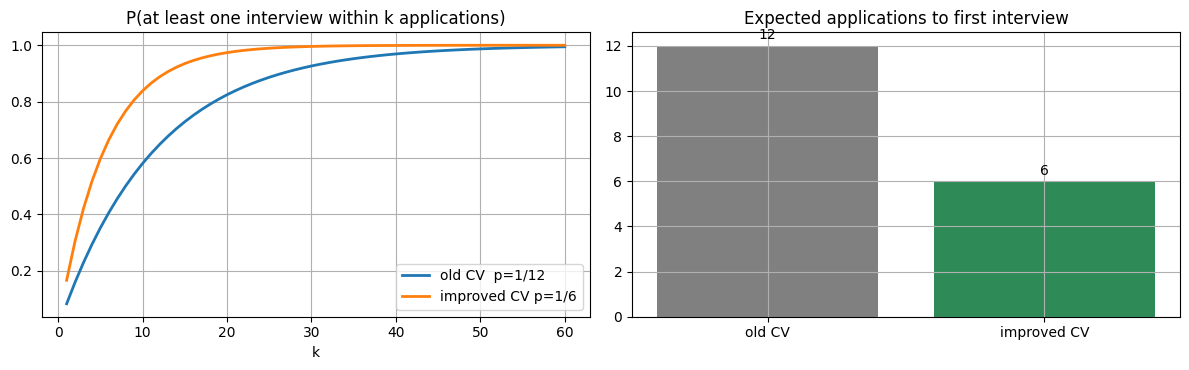

Saving per success: 6 applications = ₹300


In [19]:
# Compare: what if you improve your CV? p goes from 1/12 up to 1/6 (double)
p_old, p_new = 1/12, 1/6
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
k = np.arange(1, 61)
for pp, lab in [(p_old, "old CV  p=1/12"), (p_new, "improved CV p=1/6")]:
    ax[0].plot(k, stats.geom.cdf(k, pp), lw=2, label=lab)
ax[0].set_title("P(at least one interview within k applications)"); ax[0].legend(); ax[0].set_xlabel("k")

ax[1].bar(["old CV", "improved CV"], [1/p_old, 1/p_new], color=["gray", "seagreen"])
ax[1].set_title("Expected applications to first interview")
for i, v in enumerate([1/p_old, 1/p_new]):
    ax[1].text(i, v + 0.3, f"{v:.0f}", ha="center")
plt.tight_layout(); plt.show()

print(f"Saving per success: {(1/p_old - 1/p_new):.0f} applications = ₹{(1/p_old - 1/p_new)*cost:.0f}")

### 💡 Insights from Case Study 3
* **Halving the wait requires doubling p** (E[X] = 1/p). Improving quality of each attempt (better CV, better product, better script) has a *multiplicative* payoff. Just "trying more" has only a linear one.
* **Plan for the tail, not the average:** the mean is 12 applications, but to be 90% sure you must plan for ~27, more than double.
* The same maths applies to: attempts to pass a driving test, number of penalty kicks until a miss, number of website visitors until the first purchase (p = conversion rate), number of packets sent until a successful delivery, or tries until a server request succeeds (retry logic).

### Bonus: Website conversion, "How many visitors until first purchase?"

In [20]:
conv = 0.03                      # 3% conversion rate
X = stats.geom(conv)
print(f"Expected visitors per first purchase: {X.mean():.1f}")
print(f"P(first purchase within first 10 visitors): {X.cdf(10):.3f}")
print(f"Visitors needed for 95% chance of at least one purchase: {int(X.ppf(0.95))}")

# Ad campaign: cost per visitor Rs 4 -> expected cost per acquisition
cpv = 4
print(f"\nExpected ad cost per acquisition (CPA) = ₹{cpv} x {X.mean():.1f} = ₹{cpv * X.mean():.0f}")
print("If conversion improves 3% -> 4%, CPA drops to ₹", round(cpv / 0.04))

Expected visitors per first purchase: 33.3
P(first purchase within first 10 visitors): 0.263
Visitors needed for 95% chance of at least one purchase: 99

Expected ad cost per acquisition (CPA) = ₹4 x 33.3 = ₹133
If conversion improves 3% -> 4%, CPA drops to ₹ 100


## 13. Estimating p from Real Data (Maximum Likelihood)

In practice p is **unknown**. If we record how many trials each of *m* independent "runs" needed to get its first success — $x_1,\dots,x_m$ — then the maximum likelihood estimate is

$$\hat p=\frac{1}{\bar x}=\frac{m}{\sum x_i}$$

(the reciprocal of the average waiting time). Let's pretend a call-centre supervisor recorded the "calls until first sale" for 40 agents' shifts.

Observed waits: [ 6 45 31 22 41  4  4  6 15 17 12 12  5  3 19 40  1  7  8 11  5  3  4  6
 51  6 15  1  7 11  5  3  6  1  2  3  9 33  3 15]

Sample mean wait = 12.45
Estimated p̂ = 1/mean = 0.0803   (true p = 0.08)


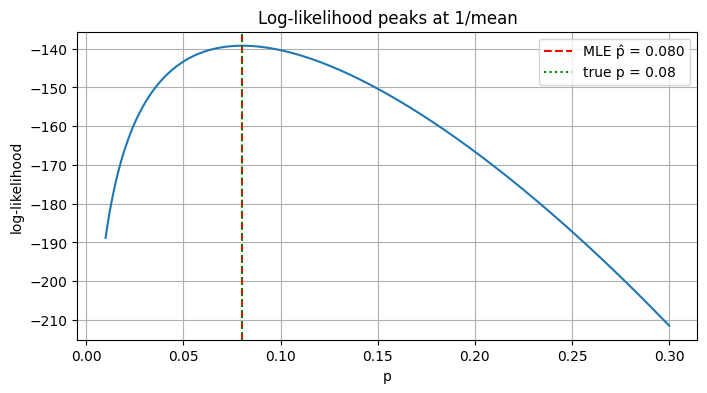

In [21]:
true_p = 0.08
observed = rng.geometric(true_p, 40)      # pretend this is real recorded data
print("Observed waits:", observed)

p_hat = 1 / observed.mean()
print(f"\nSample mean wait = {observed.mean():.2f}")
print(f"Estimated p̂ = 1/mean = {p_hat:.4f}   (true p = {true_p})")

# Likelihood curve peaks at p_hat
ps = np.linspace(0.01, 0.3, 300)
loglik = [np.sum(stats.geom.logpmf(observed, pp)) for pp in ps]
plt.plot(ps, loglik); plt.axvline(p_hat, color="red", ls="--", label=f"MLE p̂ = {p_hat:.3f}")
plt.axvline(true_p, color="green", ls=":", label=f"true p = {true_p}")
plt.xlabel("p"); plt.ylabel("log-likelihood"); plt.title("Log-likelihood peaks at 1/mean"); plt.legend(); plt.show()

In [22]:
# How accurate is p̂ as the amount of data grows?
for m in (10, 40, 200, 2000):
    ests = [1 / rng.geometric(true_p, m).mean() for _ in range(2000)]
    print(f"m = {m:4d} runs:  mean p̂ = {np.mean(ests):.4f},  SD of p̂ = {np.std(ests):.4f}")

m =   10 runs:  mean p̂ = 0.0883,  SD of p̂ = 0.0287
m =   40 runs:  mean p̂ = 0.0818,  SD of p̂ = 0.0126
m =  200 runs:  mean p̂ = 0.0804,  SD of p̂ = 0.0054


m = 2000 runs:  mean p̂ = 0.0801,  SD of p̂ = 0.0017


More data → the estimate is tighter around the truth (the Law of Large Numbers at work).

### Goodness of fit: does real data even look geometric?
Compare observed frequencies with the fitted geometric model (a simple visual check).

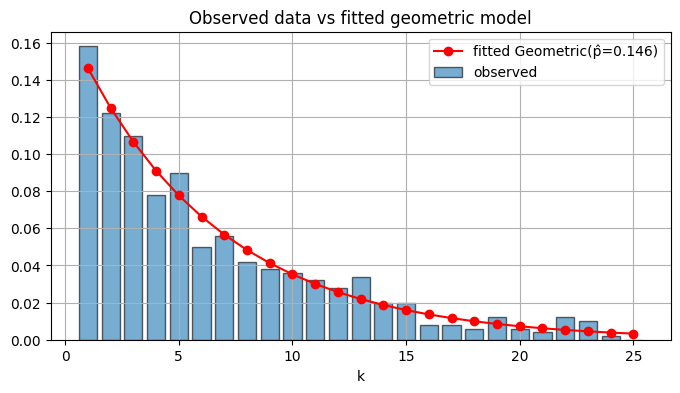

In [23]:
data = rng.geometric(0.15, 500)                 # pretend real data
p_hat = 1 / data.mean()
k = np.arange(1, 26)
obs = np.array([(data == kk).mean() for kk in k])

plt.bar(k, obs, alpha=0.6, label="observed", edgecolor="black")
plt.plot(k, stats.geom.pmf(k, p_hat), "ro-", label=f"fitted Geometric(p̂={p_hat:.3f})")
plt.legend(); plt.xlabel("k"); plt.title("Observed data vs fitted geometric model"); plt.show()

## 14. Geometric vs Binomial vs Negative Binomial

| | Fixed | Random variable | Distribution |
|---|---|---|---|
| Binomial | **n** trials | # of successes | B(n, p) |
| Geometric | stop at **1st success** | # of trials | Geom(p) |
| Negative binomial | stop at **r-th success** | # of trials | NB(r, p) |

* Geometric = Negative Binomial with r = 1.
* The sum of r independent Geometric(p) variables is Negative Binomial.
* Geometric is the *discrete* analogue of the **Exponential** distribution (both are memoryless "waiting-time" models).

In [24]:
# Sum of r geometric variables = negative binomial (trials until r-th success)
r, p = 3, 0.25
sums = rng.geometric(p, (200_000, r)).sum(axis=1)
print("Mean of sum of 3 geometrics:", sums.mean().round(3), " theory r/p =", r/p)
print("Var  of sum of 3 geometrics:", sums.var().round(3),  " theory r(1-p)/p^2 =", r*(1-p)/p**2)

# Exponential link: for small p, Geometric waiting time ≈ Exponential
p = 0.01
geo = rng.geometric(p, 200_000)
expo = rng.exponential(1/p, 200_000)
print("\nSmall p: Geometric mean/SD =", geo.mean().round(1), geo.std().round(1),
      "| Exponential mean/SD =", expo.mean().round(1), expo.std().round(1))

Mean of sum of 3 geometrics: 11.98  theory r/p = 12.0
Var  of sum of 3 geometrics: 36.164  theory r(1-p)/p^2 = 36.0

Small p: Geometric mean/SD = 99.9 99.4 | Exponential mean/SD = 100.3 100.2


## 15. Key Insights, Cheat-Sheet & Practice

### Formulas (convention A: X = number of trials, X = 1, 2, 3, ...)
| Item | Formula |
|---|---|
| PMF | $P(X=k)=q^{k-1}p$ |
| CDF | $P(X\le k)=1-q^k$ |
| Survival | $P(X>k)=q^k$ |
| Mean | $1/p$ |
| Variance | $q/p^2$ |
| Std dev | $\sqrt q/p$ |
| Mode | 1 |
| Median | $\lceil \ln 0.5/\ln q\rceil$ |
| Trials for confidence c | $k=\lceil \ln(1-c)/\ln(1-p)\rceil$ |
| MLE of p | $1/\bar x$ |
| Memoryless | $P(X>s+t\mid X>s)=P(X>t)$ |

### Top real-life insights
1. **Expected waiting time = 1 / p.** Rarer events → proportionally longer waits.
2. **The mean is not the "typical" wait.** Distribution is right-skewed: median < mean, mode = 1.
3. **Variability is huge:** SD ≈ mean for small p, so short and very long waits are both common. Plan to a percentile (e.g. 90% or 95%), not to the average.
4. **Memorylessness:** past failures don't change the future chance, so beware the gambler's fallacy and "sunk-cost / it's due" thinking.
5. **Improve p, don't just repeat:** doubling p halves the expected wait; the cost per success scales with 1/p.
6. **Long streaks without success are normal** (P(X>k) = qᵏ) and shouldn't by themselves be read as proof that something has changed. But *very* unlikely streaks are useful alarm signals (quality control, fraud, monitoring).
7. **Watch the convention** (trials vs failures) and the assumptions (independent, constant p). If p changes over time or trials are dependent, the geometric model breaks down.

### Practice problems
1. A basketball player makes 60% of her free throws. What is the probability that her first miss occurs on her 4th shot? What's the expected number of shots until the first miss?
2. The probability of a machine passing an inspection is 0.9. Find the probability that the first failure occurs at or after the 8th inspection.
3. A lottery has a 1-in-50 chance of winning. How many tickets must you buy to be 80% sure of at least one win? What's the expected number?
4. A server request succeeds with probability 0.7. A client retries until success. What's the mean and variance of the number of attempts? What's P(more than 3 attempts)?
5. Show by simulation that for Geometric(p=0.05), P(X > 40 | X > 20) = P(X > 20).
6. A marketer observes waits (visitors until first purchase) of [22, 41, 9, 65, 30, 12, 50, 18]. Estimate the conversion rate and the probability that a new site visit sequence needs more than 60 visitors.
7. Repeat Case Study 1 for p = 0.02. How do the mean, median and 95% budgets change?